In [2]:
import wandb

api = wandb.Api()


def fetch_all_runs(entity: str, project: str):
    runs = api.runs(f"{entity}/{project}")
    _data = []
    for run in runs:
        print(f"Run Name: {run.name}, Run ID: {run.id}")
        for row in run.scan_history():
            _data.append(row)
    return _data


data = fetch_all_runs("yaxing_li", "graph-hyperparam-tuning")

True
True
Run Name: hyperparam_exp, Run ID: y03uqchj
Run Name: hyperparam_exp, Run ID: powpzi1u


In [6]:
import pandas as pd

df = pd.DataFrame(data)

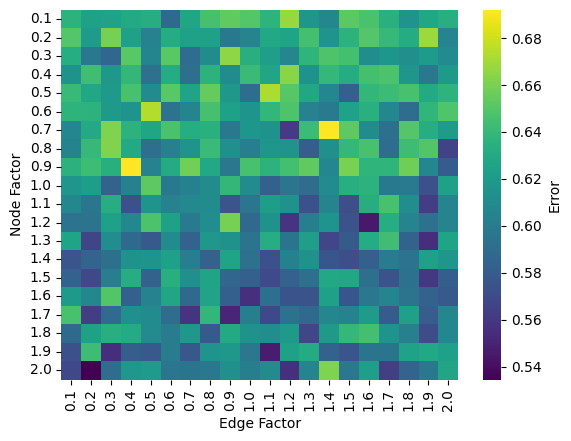

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

aggregated_df = df.groupby(['node_factor', 'edge_factor']).agg({'error': 'mean'}).reset_index()
heatmap_data = aggregated_df.pivot(index='node_factor', columns='edge_factor', values='error')

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="viridis",
    cbar_kws={"label": "Error"}
)

plt.xlabel("Edge Factor")
plt.ylabel("Node Factor")

plt.savefig("results/Code Dec 26 - heatmap.png", dpi=300)
plt.show()
